In [2]:
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [3]:
import sys
!{sys.executable} -m pip install opencv-python

In [4]:
import cv2
print(cv2.__version__)

4.13.0


In [5]:
import torch
from diffusers import StableDiffusionInpaintPipeline

In [6]:
import sys
print(sys.executable)

C:\Users\Admin\anaconda3\envs\outpaint\python.exe


In [7]:
model_id = "runwayml/stable-diffusion-inpainting"

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

C:\Users\Admin\anaconda3\envs\outpaint\lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\text_encoder
Key                                | Status     | Details
-----------------------------------+------------+--------
text_model.embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: C:\Users\Admin\.cache\huggingface\hub\models--runwayml--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\safety_checker
Key                                               | Status     | Details
--------------------------------------------------+------------+--------
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |        

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
import os
print(os.getcwd())

C:\Users\Admin\Desktop\OutpaintingNeuralNetworkProject\AIModel


In [11]:
image = Image.open("images/input.jpg").convert("RGB")

(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

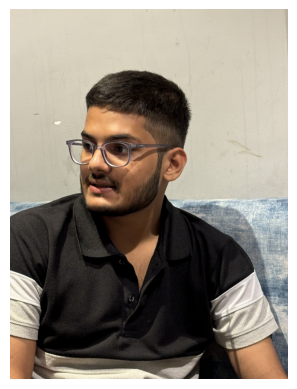

In [12]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("images/input.jpg").convert("RGB")

plt.imshow(image)
plt.axis("off")

(np.float64(-0.5), np.float64(3279.5), np.float64(4031.5), np.float64(-0.5))

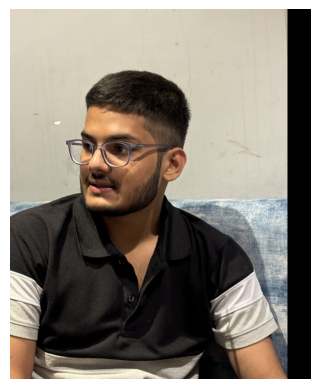

In [14]:
width, height = image.size

new_width = width + 256
new_height = height

# Create black canvas
new_image = Image.new("RGB", (new_width, new_height), (0,0,0))

# Paste original image
new_image.paste(image, (0,0))

plt.imshow(new_image)
plt.axis("off")

(np.float64(-0.5), np.float64(3279.5), np.float64(4031.5), np.float64(-0.5))

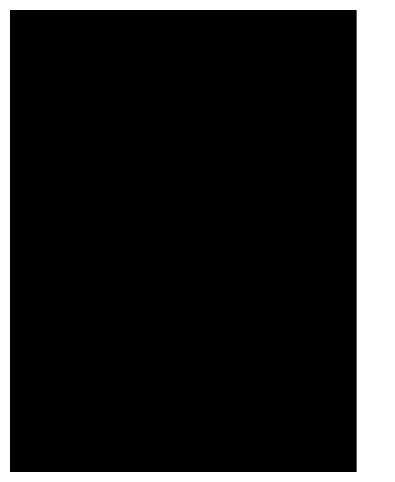

In [16]:
mask = np.zeros((new_height, new_width), dtype=np.uint8)

# White region where AI should generate
mask[:, width:new_width] = 255

mask_image = Image.fromarray(mask)

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray", vmin=0, vmax=255)
plt.axis("off")

In [17]:
print(mask[:, width:new_width].mean())

255.0


  0%|          | 0/50 [00:00<?, ?it/s]

C:\Users\Admin\anaconda3\envs\outpaint\lib\site-packages\diffusers\image_processor.py:142: RuntimeWarning: invalid value encountered in cast
  images = (images * 255).round().astype("uint8")
Potential NSFW content was detected in one or more images. A black image will be returned instead. Try again with a different prompt and/or seed.


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

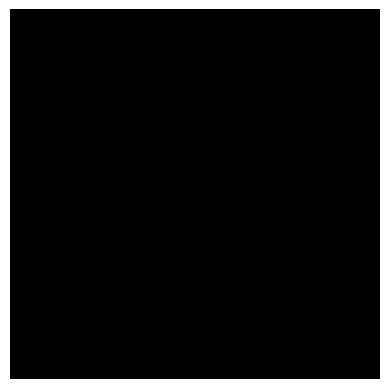

In [18]:
prompt = "realistic background continuation"

result = pipe(
    prompt=prompt,
    image=new_image,
    mask_image=mask_image
).images[0]

plt.imshow(result)
plt.axis("off")